In [1]:
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from numpy import NaN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import glob

import numpy as np
import pandas as pd

from sklearn import preprocessing
from sklearn.model_selection import train_test_split

2023-04-06 15:11:28.878758: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-06 15:11:28.975184: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-04-06 15:11:29.492726: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2023-04-06 15:11:29.492777: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] 

In [2]:
# Saving all .csv files in folder to list.
path = "cav/"
files = [file for file in glob.glob(path + "**/*.csv", recursive=True)]

In [3]:
[print(f) for f in files]

cav/Fuzzy_dataset.csv
cav/RPM_dataset.csv
cav/gear_dataset.csv
cav/normal_run_data.csv
cav/DoS_dataset.csv


[None, None, None, None, None]

In [4]:
# Reading all the csv files into dataframes and putting thoose DFs to one list.

dataset = [pd.read_csv(f) for f in files]

In [5]:
# shape of the each files

for d in dataset:
    print(d.shape)


(3838859, 12)
(4621701, 12)
(4443141, 12)
(988871, 1)
(3665770, 12)


In [6]:
def changecolumn(dataset, AttackType):
    df = pd.read_csv(dataset).sample(frac = 0.1, random_state = 20, replace = False).reset_index(drop=True)
    df.columns = ["Timestamp", "CAN ID", "Byte", "DATA[0]","DATA[1]","DATA[2]","DATA[3]","DATA[4]","DATA[5]","DATA[6]","DATA[7]","AttackType"]
    df['AttackType'] = np.where(df['AttackType'] == 'T',AttackType, 'Normal')
    df.dropna()
    return df


dfDos = changecolumn('cav/DoS_dataset.csv','DoS')
dfFuzzy = changecolumn('cav/Fuzzy_dataset.csv','Fuzzy')
dfGear = changecolumn('cav/gear_dataset.csv','Gear-Spooing')
dfRPM = changecolumn('cav/RPM_dataset.csv','RPM-Spoofing')
frames = [dfDos, dfFuzzy, dfGear, dfRPM]
df = pd.concat(frames)
print(df.head(10))
print(df.shape)

      Timestamp CAN ID  Byte DATA[0] DATA[1] DATA[2] DATA[3] DATA[4] DATA[5]  \
0  1.478200e+09   0000     8      00      00      00      00      00      00   
1  1.478201e+09   0131     8      1b      80      00      00      3f      7f   
2  1.478199e+09   00a1     8      80      89      00      00      24      00   
3  1.478200e+09   0260     8      18      21      22      30      08      8f   
4  1.478201e+09   02c0     8      14      00      00      00      00      00   
5  1.478200e+09   0130     8      0b      80      00      ff      08      80   
6  1.478200e+09   0370     8      00      20      00      00      00      00   
7  1.478199e+09   04f0     8      00      00      00      80      00      69   
8  1.478199e+09   0130     8      05      80      00      ff      0b      80   
9  1.478198e+09   0131     8      f7      7f      00      00      4c      7f   

  DATA[6] DATA[7] AttackType  
0      00      00        DoS  
1      0e      a6     Normal  
2      00      00     Norm

In [7]:
# dataset shape

dataset = df.dropna()
print('shape of the data',dataset.shape)
print(dataset['AttackType'].value_counts())

shape of the data (1636855, 12)
Normal          1403673
RPM-Spoofing      65439
Gear-Spooing      60016
DoS               58469
Fuzzy             49258
Name: AttackType, dtype: int64


In [8]:
# checking the datatypes of each features
#dataset.dtypes
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1636855 entries, 0 to 462169
Data columns (total 12 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   Timestamp   1636855 non-null  float64
 1   CAN ID      1636855 non-null  object 
 2   Byte        1636855 non-null  int64  
 3   DATA[0]     1636855 non-null  object 
 4   DATA[1]     1636855 non-null  object 
 5   DATA[2]     1636855 non-null  object 
 6   DATA[3]     1636855 non-null  object 
 7   DATA[4]     1636855 non-null  object 
 8   DATA[5]     1636855 non-null  object 
 9   DATA[6]     1636855 non-null  object 
 10  DATA[7]     1636855 non-null  object 
 11  AttackType  1636855 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 162.3+ MB


In [9]:
def changecolumntype(df):
    for column in df[['CAN ID', 'DATA[0]', 'DATA[1]', 'DATA[2]', 'DATA[3]', 'DATA[4]', 'DATA[5]', 'DATA[6]', 'DATA[7]']]:
        df[column] = df[column].apply(lambda x: int(str(x), base=16))
    return df

dataset = changecolumntype(dataset)
print(dataset.dtypes)


/tmp/ipykernel_1415158/1645856272.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].apply(lambda x: int(str(x), base=16))


Timestamp     float64
CAN ID          int64
Byte            int64
DATA[0]         int64
DATA[1]         int64
DATA[2]         int64
DATA[3]         int64
DATA[4]         int64
DATA[5]         int64
DATA[6]         int64
DATA[7]         int64
AttackType     object
dtype: object


In [10]:
# actual dataset

dataset.head(10)

,Timestamp,CAN ID,Byte,DATA[0],DATA[1],DATA[2],DATA[3],DATA[4],DATA[5],DATA[6],DATA[7],AttackType
0,1.478200e+09,0,8,0,0,0,0,0,0,0,0,DoS
1,1.478201e+09,305,8,27,128,0,0,63,127,14,166,Normal
2,1.478199e+09,161,8,128,137,0,0,36,0,0,0,Normal
3,1.478200e+09,608,8,24,33,34,48,8,143,112,5,Normal
4,1.478201e+09,704,8,20,0,0,0,0,0,0,0,Normal
5,1.478200e+09,304,8,11,128,0,255,8,128,4,136,Normal
6,1.478200e+09,880,8,0,32,0,0,0,0,0,0,Normal
7,1.478199e+09,1264,8,0,0,0,128,0,105,209,19,Normal
8,1.478199e+09,304,8,5,128,0,255,11,128,12,237,Normal
9,1.478198e+09,305,8,247,127,0,0,76,127,13,231,Normal


In [11]:
#dataset['Message'] = df.iloc[:,3:11].apply(lambda x: ''.join(x.astype(str)), axis = 1)
#dataset.head(10)

In [12]:
import datetime
newdf = dataset.copy(deep = True)
dateformat = "%Y-%m-%d %H:%M:%S.%f"
dataset['Timestamp'] = dataset['Timestamp'].apply(lambda x: datetime.datetime.fromtimestamp(float(x)).strftime(dateformat))
print(dataset.dtypes)
dataset.head(10)

Timestamp     object
CAN ID         int64
Byte           int64
DATA[0]        int64
DATA[1]        int64
DATA[2]        int64
DATA[3]        int64
DATA[4]        int64
DATA[5]        int64
DATA[6]        int64
DATA[7]        int64
AttackType    object
dtype: object


/tmp/ipykernel_1415158/3733542703.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['Timestamp'] = dataset['Timestamp'].apply(lambda x: datetime.datetime.fromtimestamp(float(x)).strftime(dateformat))


,Timestamp,CAN ID,Byte,DATA[0],DATA[1],DATA[2],DATA[3],DATA[4],DATA[5],DATA[6],DATA[7],AttackType
0,2016-11-03 15:08:43.044157,0,8,0,0,0,0,0,0,0,0,DoS
1,2016-11-03 15:24:35.989254,305,8,27,128,0,0,63,127,14,166,Normal
2,2016-11-03 14:54:13.788681,161,8,128,137,0,0,36,0,0,0,Normal
3,2016-11-03 15:06:50.286119,608,8,24,33,34,48,8,143,112,5,Normal
4,2016-11-03 15:26:04.139714,704,8,20,0,0,0,0,0,0,0,Normal
5,2016-11-03 15:03:07.624543,304,8,11,128,0,255,8,128,4,136,Normal
6,2016-11-03 15:06:31.658461,880,8,0,32,0,0,0,0,0,0,Normal
7,2016-11-03 14:55:47.812754,1264,8,0,0,0,128,0,105,209,19,Normal
8,2016-11-03 14:46:48.226079,304,8,5,128,0,255,11,128,12,237,Normal
9,2016-11-03 14:40:52.891089,305,8,247,127,0,0,76,127,13,231,Normal


In [13]:
# binary classification ##

In [14]:
# changing attack category

bin_label = pd.DataFrame(dataset.AttackType.map(lambda x:'Normal' if x=='Normal' else 'ATTACK'))

In [15]:
bin_data = dataset.copy()
bin_data['AttackType'] = bin_label

In [16]:
from sklearn.preprocessing import LabelEncoder

LE1 = LabelEncoder()

enc_label = bin_label.apply(LE1.fit_transform)
bin_data['intrusion']= enc_label

In [17]:
LE1.classes_

array(['ATTACK', 'Normal'], dtype=object)

In [18]:
bin_data.head()

,Timestamp,CAN ID,Byte,DATA[0],DATA[1],DATA[2],DATA[3],DATA[4],DATA[5],DATA[6],DATA[7],AttackType,intrusion
0,2016-11-03 15:08:43.044157,0,8,0,0,0,0,0,0,0,0,ATTACK,0
1,2016-11-03 15:24:35.989254,305,8,27,128,0,0,63,127,14,166,Normal,1
2,2016-11-03 14:54:13.788681,161,8,128,137,0,0,36,0,0,0,Normal,1
3,2016-11-03 15:06:50.286119,608,8,24,33,34,48,8,143,112,5,Normal,1
4,2016-11-03 15:26:04.139714,704,8,20,0,0,0,0,0,0,0,Normal,1


In [19]:
# one-hot-encoding for attack label

bin_data = pd.get_dummies(bin_data,columns=['AttackType'],prefix="",prefix_sep="")
bin_data['AttackType']= bin_label
bin_data

,Timestamp,CAN ID,Byte,DATA[0],DATA[1],DATA[2],DATA[3],DATA[4],DATA[5],DATA[6],DATA[7],intrusion,ATTACK,Normal,AttackType
0,2016-11-03 15:08:43.044157,0,8,0,0,0,0,0,0,0,0,0,1,0,ATTACK
1,2016-11-03 15:24:35.989254,305,8,27,128,0,0,63,127,14,166,1,0,1,Normal
2,2016-11-03 14:54:13.788681,161,8,128,137,0,0,36,0,0,0,1,0,1,Normal
3,2016-11-03 15:06:50.286119,608,8,24,33,34,48,8,143,112,5,1,0,1,Normal
4,2016-11-03 15:26:04.139714,704,8,20,0,0,0,0,0,0,0,1,0,1,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
462165,2016-11-03 12:44:59.108226,809,8,220,183,126,20,17,32,0,20,1,0,1,Normal
462166,2016-11-03 13:00:16.888570,305,8,242,127,0,0,58,127,12,131,1,0,1,Normal
462167,2016-11-03 15:21:55.596377,305,8,242,127,0,0,64,127,6,22,1,0,1,Normal
462168,2016-11-03 13:07:04.353120,704,8,21,0,0,0,0,0,0,0,1,0,1,Normal


In [20]:
## feature extraction ##

In [21]:
# final data for binary classification ##

In [22]:
# creating dataframe with only numeric attributes of binary class and encoded label attribute
numeric_col = dataset.select_dtypes(include = 'number').columns

numeric_bin = bin_data[numeric_col]
numeric_bin['intrusion'] = bin_data['intrusion']

/tmp/ipykernel_1415158/1352549749.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  numeric_bin['intrusion'] = bin_data['intrusion']


In [23]:
# extracting features which have more than 0.5 correlation (pearson correlation coefficient)

corr=numeric_bin.corr()
corr_y = abs(corr['intrusion'])
highest_corr = corr_y[corr_y >0.001]
highest_corr.sort_values(ascending=True)

DATA[6]      0.005097
CAN ID       0.020673
DATA[0]      0.053094
DATA[1]      0.077639
DATA[4]      0.080123
DATA[5]      0.131104
DATA[2]      0.147786
DATA[7]      0.225358
DATA[3]      0.339619
intrusion    1.000000
Name: intrusion, dtype: float64

In [24]:
#numeric_bin = bin_data[["CAN ID","DATA[0]","DATA[1]","DATA[2]","DATA[3]","DATA[4]","DATA[5]","DATA[6]","DATA[7]"]]


In [25]:

#bin_data = numeric_bin.join(bin_data[['intrusion','Normal','ATTACK','AttackType']])

In [26]:
#bin_data.to_csv("binary_cav.csv")
bin_data

,Timestamp,CAN ID,Byte,DATA[0],DATA[1],DATA[2],DATA[3],DATA[4],DATA[5],DATA[6],DATA[7],intrusion,ATTACK,Normal,AttackType
0,2016-11-03 15:08:43.044157,0,8,0,0,0,0,0,0,0,0,0,1,0,ATTACK
1,2016-11-03 15:24:35.989254,305,8,27,128,0,0,63,127,14,166,1,0,1,Normal
2,2016-11-03 14:54:13.788681,161,8,128,137,0,0,36,0,0,0,1,0,1,Normal
3,2016-11-03 15:06:50.286119,608,8,24,33,34,48,8,143,112,5,1,0,1,Normal
4,2016-11-03 15:26:04.139714,704,8,20,0,0,0,0,0,0,0,1,0,1,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
462165,2016-11-03 12:44:59.108226,809,8,220,183,126,20,17,32,0,20,1,0,1,Normal
462166,2016-11-03 13:00:16.888570,305,8,242,127,0,0,58,127,12,131,1,0,1,Normal
462167,2016-11-03 15:21:55.596377,305,8,242,127,0,0,64,127,6,22,1,0,1,Normal
462168,2016-11-03 13:07:04.353120,704,8,21,0,0,0,0,0,0,0,1,0,1,Normal


In [27]:
# counting the attacks for binary

bin_data['AttackType'].value_counts()

Normal    1403673
ATTACK     233182
Name: AttackType, dtype: int64

In [28]:
# classifier for binary classification dataset

import warnings
warnings.filterwarnings("ignore")


X = bin_data.iloc[:,1:11].to_numpy() # dataset excluding target attribute (encoded, one-hot-encoded,original)
y = bin_data['intrusion'] # target attribute

X_train, X_validation, Y_train, Y_validation = train_test_split(X, y, test_size=0.20, random_state=1)

      


In [29]:
X_train = preprocessing.scale(X_train)
X_train = preprocessing.normalize(X_train)

In [30]:
X_validation = preprocessing.scale(X_validation)
X_validation = preprocessing.normalize(X_validation)

In [31]:
print(len(X_train), "Training sequences",X_train.shape)
print(len(X_validation), "Validation sequences",X_validation.shape)

1309484 Training sequences (1309484, 10)
327371 Validation sequences (327371, 10)


In [32]:
X_train = np.reshape(X_train,(X_train.shape[0],X_train.shape[1],1))
X_validation = np.reshape(X_validation,(X_validation.shape[0],X_validation.shape[1],1))

In [33]:
X_train.shape

(1309484, 10, 1)

In [35]:
# Using tanh and sigmoid as activation functions

import time

Model = keras.Sequential([

        keras.layers.Conv2D(96,(4,4),input_shape=(X_train.shape[1],X_train.shape[2],1),activation='relu',padding='same'),
        keras.layers.Conv2D(64,(3,3),activation="relu",padding='same'),
        keras.layers.Conv2D(32,(2,2),activation="relu",padding='same'),
        keras.layers.Dropout(0.5),
        keras.layers.Flatten(),
        keras.layers.Dense(512,activation="relu"),
        keras.layers.Dense(128,activation="relu"),
        keras.layers.Dense(32,activation="relu"),
        keras.layers.Dense(2,activation="softmax"),
    
    
    ])

Model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])
start_time = time.time()
#Training the model
history = Model.fit(X_train, Y_train, epochs=3, batch_size=64,validation_data = (X_validation, Y_validation)) 
Model.summary()

# Final evaluation of the model
scores = Model.evaluate(X_validation, Y_validation, verbose=0)
delta = time.time()- start_time
print("Accuracy: %.2f%%" % (scores[1]*100))
print("Training time: %.2f sec" % (delta))

Epoch 1/3
   20/20461 [..............................] - ETA: 1:54 - loss: 0.4974 - sparse_categorical_accuracy: 0.8172  

2023-04-06 15:12:45.363835: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_1/dropout_1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


20461/20461 [==============================] - 172s 8ms/step - loss: 0.0078 - sparse_categorical_accuracy: 0.9979 - val_loss: 0.0014 - val_sparse_categorical_accuracy: 0.9997
Epoch 2/3
20461/20461 [==============================] - 171s 8ms/step - loss: 0.0021 - sparse_categorical_accuracy: 0.9996 - val_loss: 0.0014 - val_sparse_categorical_accuracy: 0.9998
Epoch 3/3
20461/20461 [==============================] - 172s 8ms/step - loss: 0.0018 - sparse_categorical_accuracy: 0.9997 - val_loss: 0.0010 - val_sparse_categorical_accuracy: 0.9999
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 10, 1, 96)         1632      
                                                                 
 conv2d_4 (Conv2D)           (None, 10, 1, 64)         55360     
                                                                 
 conv2d_5 (Conv2D)           (None, 1

In [36]:
from sklearn.metrics import (precision_score, recall_score,f1_score, accuracy_score,mean_squared_error
                             ,mean_absolute_error,roc_auc_score,roc_curve,confusion_matrix)
from sklearn import metrics

In [37]:
y_pred = Model.predict(X_validation, verbose = 0)
# predict crisp classes for test set
yhat_classes = np.argmax(y_pred,axis=1)
# reduce to 1d array
yhat_probs = y_pred[:, 0]

 
# accuracy: (tp + tn) / (p + n)
accuracy = accuracy_score(Y_validation, yhat_classes)
print('Accuracy: %f' % accuracy)
# precision tp / (tp + fp)
precision = precision_score(Y_validation, yhat_classes)
print('Precision: %f' % precision)
# recall: tp / (tp + fn)
recall = recall_score(Y_validation, yhat_classes)
print('Recall: %f' % recall)
# f1: 2 tp / (2 tp + fp + fn)
f1 = f1_score(Y_validation, yhat_classes)
print('F1 score: %f' % f1)


# ROC AUC
auc = roc_auc_score(Y_validation, yhat_probs)
print('ROC AUC: %f' % auc)
# confusion matrix
matrix = confusion_matrix(Y_validation, yhat_classes)
print(matrix)
# false alaram rate
false_alaram_rate = matrix[1,0]/(matrix[1,0]+matrix[0,0])
print('false alaram rate: %f' % false_alaram_rate)

Accuracy: 0.999850
Precision: 0.999850
Recall: 0.999975
F1 score: 0.999913
ROC AUC: 0.000045
[[ 46466     42]
 [     7 280856]]
false alaram rate: 0.000151


In [38]:
#loss, accuracy = Model.evaluate(x_test, y_test, verbose=1)
loss_v, accuracy_v = Model.evaluate(X_validation, Y_validation, verbose=1)
print("Test: accuracy = %f  ;  loss_v = %f" % (accuracy_v, loss_v))
#odel.save("model.h5")

10231/10231 [==============================] - 50s 5ms/step - loss: 0.0010 - sparse_categorical_accuracy: 0.9999
Test: accuracy = 0.999850  ;  loss_v = 0.001039


NameError: name 'model' is not defined

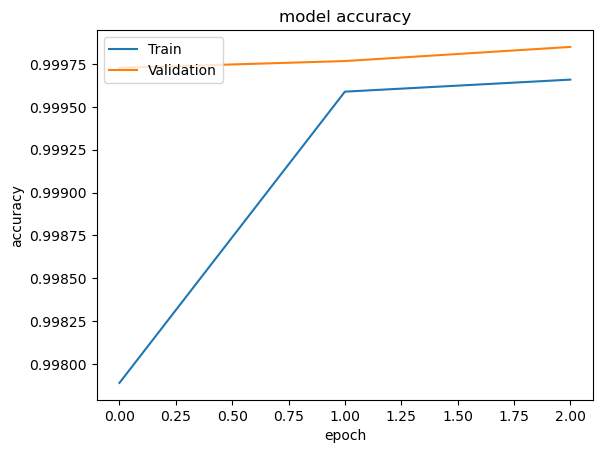

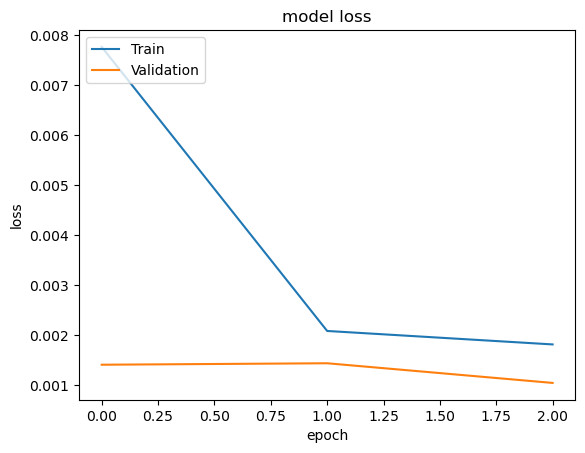

In [41]:
import matplotlib.pyplot as plt

# summarize history for accuracy
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()